# Get started with Qiskit in the classroom

**Notebook:** `Simple_Quantum_Circuits_with_Qiskit.ipynb`

This classroom notebook is an original, concise adaptation of selected concepts from the IBM Quantum Learning module:

[IBM Quantum Learning — Get started with Qiskit in the classroom](https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/get-started-with-qiskit)

It covers only the selected topics necessary for knowing the basics of Quantum Computing using IBM Qiskit.

> The explanations below are paraphrased; they are not a verbatim reproduction of the IBM lesson.

## Introduction

Quantum programs are built from three basic ideas:

1. **Qubits** store quantum information.
2. **Quantum gates** transform the state of one or more qubits.
3. **Measurements** convert quantum information into classical outcomes.

Qiskit lets us describe these operations as quantum circuits and inspect or simulate their behavior with Python.

For this notebook, we use Qiskit 2.1 or newer and Qiskit Aer for local simulation.

In [1]:
# Install the packages used in this notebook.
# In Google Colab, run this cell once per fresh runtime.

%pip install -q "pylatexenc" "qiskit>=2.1.0" "qiskit-aer>=0.17.0"

In [2]:
from math import pi, sqrt
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Quantum computer

A classical computer represents information using bits. A quantum computer instead uses **quantum bits**, or **qubits**.

### Qubits

A qubit has two computational basis-states

$$
|0\rangle,\qquad |1\rangle,
$$

The states $|0\rangle$ and $|1\rangle$ are not just values.

They are the basis vectors of a two-dimensional complex vector space.

$$
|0\rangle =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
|1\rangle =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

Why they are called basis vectors? Because these two states can be used as a linear combination of $|0\rangle$ and $|1\rangle$ leading to a qubit state called "superposition".

A superposition state can be mathematically denoted as

$$
|\psi\rangle=c_0|0\rangle+c_1|1\rangle,
$$

where $c_0$ and $c_1$ are complex probability amplitudes satisfying

$$
|c_0|^2+|c_1|^2=1
$$

If the qubit is measured in the computational basis, the probabilities of observing $|0\rangle$ and $|1\rangle$ are respectively

$$
P(|0\rangle)=|c_0|^2,\qquad P(|1\rangle)=|c_1|^2.
$$

A useful parameterization is

$$
|\psi\rangle=
\cos\left(\frac{\theta}{2}\right)|0\rangle+
e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle.
$$

The relative phase $\phi$ can affect later interference, while multiplying the entire state by the same global phase does not change measurement probabilities.

In [3]:
# Example: construct a single-qubit state from theta and phi.

theta = np.pi / 2
phi = np.pi

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

psi = np.array([alpha, beta], dtype=complex)

print("alpha =", alpha)
print("beta  =", beta)
print("state vector =", psi)
print("normalization =", np.sum(np.abs(psi)**2))

alpha = 0.7071067811865476
beta  = (-0.7071067811865475+8.659560562354932e-17j)
state vector = [ 0.70710678+0.00000000e+00j -0.70710678+8.65956056e-17j]
normalization = 1.0


#### Multiple qubits

An $N$-qubit pure state can instead be a superposition of all $2^N$ computational-basis states:

$$
|\psi_N\rangle
=
\sum_{i=0}^{2^N-1}c_i|i\rangle,
\qquad
\sum_i |c_i|^2=1.
$$

For two qubits, there are four basis states:

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle.
$$

For three qubits there are eight basis states:

$$
|000\rangle, |001\rangle, |010\rangle, |011\rangle,
|100\rangle, |101\rangle, |110\rangle, |111\rangle.
$$

Qiskit follows a **little-endian** convention when basis states are displayed: qubit $q_0$ corresponds to the rightmost bit in a ket such as $|q_2q_1q_0\rangle$.

In [4]:
# Create a 3-qubit circuit and inspect its initial state |000>.

qc3 = QuantumCircuit(3)
state3 = Statevector.from_instruction(qc3)

print(state3)
print("Statevector dimension:", len(state3.data))

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))
Statevector dimension: 8


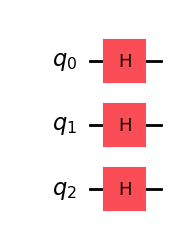

Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))


In [5]:
# Put all three qubits into superposition.
# The result has equal-magnitude amplitudes for all 8 basis states.

qc3_superposition = QuantumCircuit(3)
qc3_superposition.h([0, 1, 2])

state3_superposition = Statevector.from_instruction(qc3_superposition)

display(qc3_superposition.draw("mpl"))
print(state3_superposition)

#### Entanglement

Multiple qubits are **entangled** when the joint state cannot be written as a simple product of independent single-qubit states.

A standard example is the Bell state

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
$$

Neither qubit has an independent definite value. Measurement produces either 00 or 11, and the two outcomes are perfectly correlated.

Another Bell state,

$$
|\Psi^+\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt{2}},
$$

produces opposite computational-basis outcomes.

By contrast, $|11\rangle$ is not entangled: it is simply the tensor product $|1\rangle\otimes|1\rangle$.

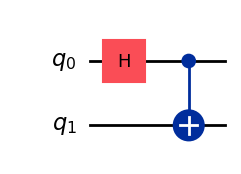

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [6]:
# Build the Bell state (|00> + |11>) / sqrt(2).

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

display(bell.draw("mpl"))

bell_state = Statevector.from_instruction(bell)
print(bell_state)

{'00': 498, '11': 526}


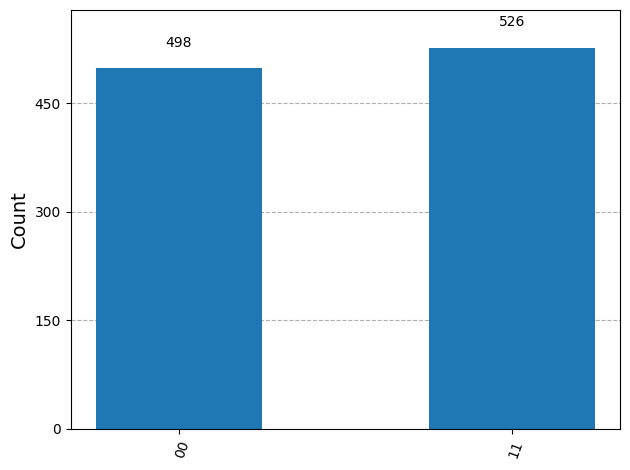

In [7]:
# Measure the Bell state many times to observe the correlation.

bell_m = QuantumCircuit(2, 2)
bell_m.h(0)
bell_m.cx(0, 1)
bell_m.measure([0, 1], [0, 1])

simulator = AerSimulator()
result = simulator.run(bell_m, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

#### Vector notation

Quantum states can be represented by column vectors. For one qubit,

$$
|0\rangle=
\begin{pmatrix}
1\\
0
\end{pmatrix},
\qquad
|1\rangle=
\begin{pmatrix}
0\\
1
\end{pmatrix}.
$$

Therefore,

$$
|\psi\rangle=a|0\rangle+b|1\rangle
\quad\longleftrightarrow\quad
\begin{pmatrix}
a\\
b
\end{pmatrix}.
$$

An \(n\)-qubit state needs a \(2^n\)-component vector. For two qubits,

$$
|00\rangle=
\begin{pmatrix}1\\0\\0\\0\end{pmatrix},\quad
|01\rangle=
\begin{pmatrix}0\\1\\0\\0\end{pmatrix},\quad
|10\rangle=
\begin{pmatrix}0\\0\\1\\0\end{pmatrix},\quad
|11\rangle=
\begin{pmatrix}0\\0\\0\\1\end{pmatrix}
$$

In [8]:
# Computational-basis vectors for two qubits.

basis = {
    "|00>": np.array([1, 0, 0, 0], dtype=complex),
    "|01>": np.array([0, 1, 0, 0], dtype=complex),
    "|10>": np.array([0, 0, 1, 0], dtype=complex),
    "|11>": np.array([0, 0, 0, 1], dtype=complex),
}

for ket, vec in basis.items():
    print(f"{ket} = {vec}")

|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|10> = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
|11> = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]


## Quantum gates

Quantum gates play the role of elementary transformations. Quantum gates are represented by **unitary matrices**, so their action is reversible.

For a state vector $|\psi\rangle$ and gate matrix $U$,

$$
|\psi_{\text{out}}\rangle=U|\psi_{\text{in}}\rangle.
$$

Below are several frequently used gates.

### Single-qubit gates

#### X gate

The Pauli-$X$ gate flips the computational-basis state:

$$
X|0\rangle=|1\rangle,\qquad X|1\rangle=|0\rangle.
$$

$$
X=
\begin{pmatrix}
0&1\\
1&0
\end{pmatrix}.
$$

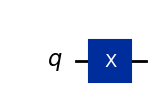

State after X|0>:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


In [9]:
qc_x = QuantumCircuit(1)
qc_x.x(0)
display(qc_x.draw("mpl"))

print("State after X|0>:")
print(Statevector.from_instruction(qc_x))

#### Hadamard gate

The Hadamard gate converts computational-basis states into equal-magnitude superpositions:

$$
H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
$$

$$
H|1\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

$$
H=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

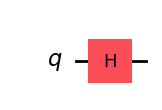

State after H|0>:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [10]:
qc_h = QuantumCircuit(1)
qc_h.h(0)
display(qc_h.draw("mpl"))

print("State after H|0>:")
print(Statevector.from_instruction(qc_h))

#### Z gate

The Pauli-$Z$ gate leaves $|0\rangle$ unchanged and changes the phase of $|1\rangle$:

$$
Z|0\rangle=|0\rangle,\qquad
Z|1\rangle=-|1\rangle.
$$

$$
Z=
\begin{pmatrix}
1&0\\
0&-1
\end{pmatrix}.
$$

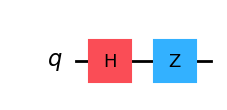

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [11]:
# H creates superposition; Z changes its relative phase.

qc_z = QuantumCircuit(1)
qc_z.h(0)
qc_z.z(0)

display(qc_z.draw("mpl"))
print(Statevector.from_instruction(qc_z))

#### T gate

The $T$ gate applies a relative phase of $\pi/4$ to the $|1\rangle$ component:

$$
T=
\begin{pmatrix}
1&0\\
0&e^{i\pi/4}
\end{pmatrix}
$$

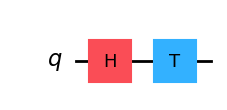

Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


In [12]:
qc_t = QuantumCircuit(1)
qc_t.h(0)
qc_t.t(0)

display(qc_t.draw("mpl"))
print(Statevector.from_instruction(qc_t))

### Multi-qubit gates

#### CNOT gate

A controlled-NOT gate has a **control** qubit and a **target** qubit. When the control is $|1\rangle$, an $X$ operation is applied to the target; when the control is $|0\rangle$, the target is unchanged.

In Qiskit:

```python
qc.cx(control, target)
```

CNOT is central to building entanglement and reversible Boolean logic.

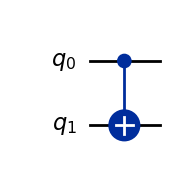

In [13]:
qc_cx = QuantumCircuit(2)
qc_cx.cx(0, 1)
display(qc_cx.draw("mpl"))

#### SWAP gate

The SWAP gate exchanges the quantum states of two qubits:

$$
|01\rangle\leftrightarrow|10\rangle
$$

A SWAP can also be decomposed into three CNOT gates.

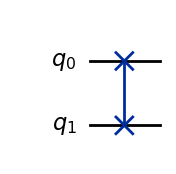

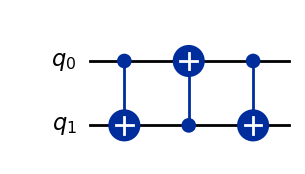

In [14]:
qc_swap = QuantumCircuit(2)
qc_swap.swap(0, 1)

display(qc_swap.draw("mpl"))
display(qc_swap.decompose().draw("mpl"))

#### Toffoli (CCX) gate

The Toffoli gate has two controls and one target. The target flips only when **both** controls are $|1\rangle$.

This makes the Toffoli gate useful when embedding AND-like behavior into a reversible quantum circuit.

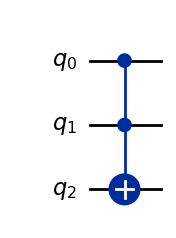

In [15]:
qc_ccx = QuantumCircuit(3)
qc_ccx.ccx(0, 1, 2)
display(qc_ccx.draw("mpl"))

## Measurements

Measurement is fundamentally different from simply reading a classical bit.

Suppose

$$
|\psi\rangle=\sum_i c_i|i\rangle.
$$

A computational-basis measurement returns one basis state $|i\rangle$ with probability

$$
P(i)=|c_i|^2.
$$

After such a measurement, the pre-measurement superposition is no longer available in the same form. In Qiskit, measurement results are written into classical bits.

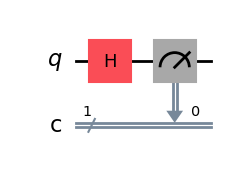

{'0': 502, '1': 498}


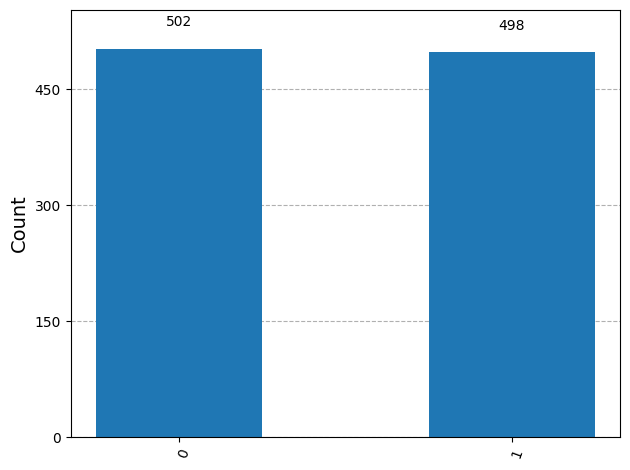

In [16]:
# Measure a qubit prepared in |+> = (|0> + |1>) / sqrt(2).

measure_demo = QuantumCircuit(1, 1)
measure_demo.h(0)
measure_demo.measure(0, 0)

display(measure_demo.draw("mpl"))

simulator = AerSimulator()
result = simulator.run(measure_demo, shots=1000).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

## Circuits

A useful way to organize quantum-computing work is to proceed from a problem description to a circuit, then adapt that circuit for hardware, execute it, and interpret the results.

### Mapping

We will map a classical **half-adder** to a reversible quantum circuit.

For classical inputs $A$ and $B$,

$$
S=A\oplus B
$$

is the sum bit, and

$$
C=A\land B
$$

is the carry bit.

A quantum circuit should not simply erase the input values, so we introduce separate qubits for the outputs. We use four qubits:

- $q_0=A$
- $q_1=B$
- $q_2=S$ (initialized to 0)
- $q_3=C$ (initialized to 0)

The circuit computes the sum using two CNOT gates:

$$
S \leftarrow S\oplus A\oplus B,
$$

and computes the carry with a Toffoli gate:

$$
C \leftarrow C\oplus(A\land B).
$$

With $S=C=0$ initially, the final output qubits hold the ordinary half-adder results.

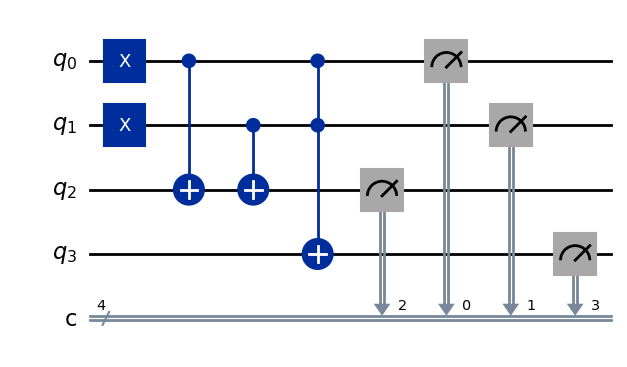

In [17]:
def quantum_half_adder(a: int, b: int) -> QuantumCircuit:
    # q0 = A, q1 = B, q2 = Sum, q3 = Carry
    if a not in (0, 1) or b not in (0, 1):
        raise ValueError("a and b must each be 0 or 1")

    qc = QuantumCircuit(4, 4)

    # Encode the classical input values in q0 and q1.
    if a == 1:
        qc.x(0)
    if b == 1:
        qc.x(1)

    # Sum: A XOR B -> q2.
    qc.cx(0, 2)
    qc.cx(1, 2)

    # Carry: A AND B -> q3.
    qc.ccx(0, 1, 3)

    # Measure all qubits.
    qc.measure(range(4), range(4))

    return qc


example = quantum_half_adder(1, 1)
display(example.draw("mpl"))

Because Qiskit displays classical results in the order $q_3q_2q_1q_0$, the measured bit string can be interpreted as

$$
|CSBA\rangle.
$$

For example, $A=B=1$ should produce

- $S=0$
- $C=1$

so the ideal final basis state is $|1011\rangle$.

In [18]:
# Simulate all four possible classical input combinations.

simulator = AerSimulator()

for a in (0, 1):
    for b in (0, 1):
        qc = quantum_half_adder(a, b)
        result = simulator.run(qc, shots=100).result()
        counts = result.get_counts()

        expected_sum = a ^ b
        expected_carry = a & b

        print(
            f"A={a}, B={b}  ->  "
            f"expected Sum={expected_sum}, Carry={expected_carry}; "
            f"counts={counts}"
        )

A=0, B=0  ->  expected Sum=0, Carry=0; counts={'0000': 100}
A=0, B=1  ->  expected Sum=1, Carry=0; counts={'0110': 100}
A=1, B=0  ->  expected Sum=1, Carry=0; counts={'0101': 100}
A=1, B=1  ->  expected Sum=0, Carry=1; counts={'1011': 100}


### Check your understanding

Verify the half-adder relation for all four input combinations:

$$
A+B=S+2C.
$$

| A | B | Sum | Carry |
|---:|---:|---:|---:|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | 0 |
| 1 | 0 | 1 | 0 |
| 1 | 1 | 0 | 1 |


---

### Source

IBM Quantum Learning, **“Get started with Qiskit in the classroom.”**  
https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/get-started-with-qiskit

Accessed for preparation of this notebook on 8 August 2026.